# Set environment

In [27]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *

### plotting
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/pipe01"
FIG_DIR = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image/fig"

# Load data

In [5]:
!ls -l /data/clintko/flow_EQAPOL_normal/pipe01

total 26506556
-rw-r--r-- 1 clintko clintko  260350632 Apr  5 15:52 model_vgg16_lr5e6_bs10_noBNorm.h5
-rw-r--r-- 1 clintko clintko       1930 Apr  5 15:51 model_vgg16_lr5e6_bs10_noBNorm_history.P
-rw-r--r-- 1 clintko clintko      10477 Apr  5 15:51 model_vgg16_lr5e6_bs10_noBNorm.yaml
-rw-r--r-- 1 clintko clintko  260350632 Apr  5 15:37 model_vgg16_lre5_bs10_noBNorm.h5
-rw-r--r-- 1 clintko clintko  260334248 Apr 11 02:05 model_vgg16_noBNorm_lr5e6_bs10_SEB.h5
-rw-r--r-- 1 clintko clintko       1930 Apr 11 02:05 model_vgg16_noBNorm_lr5e6_bs10_SEB_history.P
-rw-r--r-- 1 clintko clintko      10477 Apr 11 02:05 model_vgg16_noBNorm_lr5e6_bs10_SEB.yaml
-rw-r--r-- 1 clintko clintko  260350632 Apr 12 01:41 model_vgg16_noBNorm_lr5e6_bs50_class3.h5
-rw-r--r-- 1 clintko clintko       1930 Apr 12 01:41 model_vgg16_noBNorm_lr5e6_bs50_class3_history.P
-rw-r--r-- 1 clintko clintko      10477 Apr 12 01:41 model_vgg16_noBNorm_lr5e6_bs50_class3.yaml
-rw-r--r-- 1 clintko clintko  260334248 Apr 12 01:06 mod

In [6]:
### set up a pickle file
fname = "wrap04_tsne_1e4_N50.P"
fpath = os.path.join(DAT_DIR, fname)
file = open(fpath, 'rb')

### store the dictionary
wrap_tsne = pickle.load(file)
file.close()

In [7]:
print(wrap_tsne)

Label: Counter({0: 550, 1: 550, 2: 550})
    0: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 23

# visualization

In [20]:
print(wrap_tsne.get_index(label=0)[0:2])
print("=========================")
print(wrap_tsne.get_index(label=1)[0:2])
print("=========================")
print(wrap_tsne.get_index(label=2)[0:2])

[0, 1]
[550, 551]
[1100, 1101]


In [24]:
label[index]

array([0, 1, 2, 0, 1, 2])

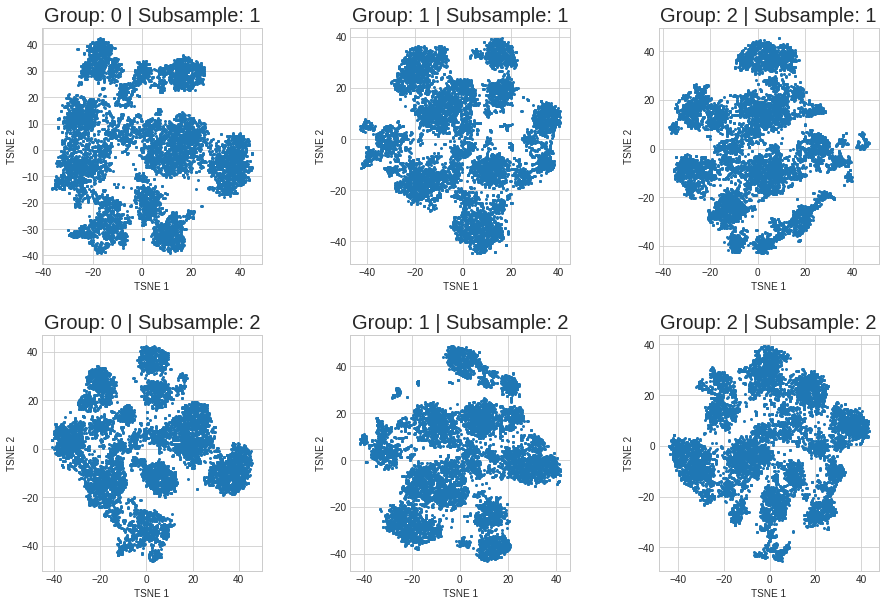

In [49]:
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(15, 10))
plt.subplots_adjust(wspace = 0.4, hspace = 0.3)
axes = axes.ravel()

###
label = wrap_tsne.label
index = [0, 550, 1100, 1, 551, 1101]
subs  = [1, 1, 1, 2, 2, 2]

for idx, idx_subs, lab, ax in zip(index, subs, label[index], axes):
    mat = wrap_tsne.get_coord(idx)
    ax.scatter(mat[:,0], mat[:, 1], s = 4)
    ax.set_xlabel("TSNE 1")
    ax.set_ylabel("TSNE 2")
    ax.set_title("Group: "     + str(lab) + " | " + "Subsample: " + str(idx_subs), 
                 fontsize=20)

plt.savefig(os.path.join(FIG_DIR, "eqapol_pipe01_dimRed.png"), dpi=300)